In [1]:
import pandas as pd
from toolbox import PredictorOGT
from ml_pipelines import models 
from sklearn.model_selection import GroupKFold

# Data clean-up

In [2]:
data_col = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
target_col = ["OGT"]

df = pd.read_csv("../data/amino-acids-counts-archaea.tsv",sep="\t",index_col=0) 
# Convert amino-acids counts to frequences 
for aa in data_col : 
    df[aa] = df[aa]/df["aa_sum"]
# Create group column by genus for CV
df["genus"] = df["SpHierarchie"].str.split("~").str[4]
df

,A,C,D,E,F,G,H,I,K,L,...,V,W,Y,aa_sum,SpName,OGT,GC,CatTemp,SpHierarchie,genus
accession_number,,,,,,,,,,,,,,,,,,,,,
GCF_900113615.1,0.114261,0.006557,0.087754,0.087395,0.032027,0.091629,0.019117,0.037128,0.016057,0.086365,...,0.094965,0.010519,0.025416,907970,Halorubrum_aquaticum,37.0,0.683,mesophile,Archaea~Methanobacteriota~Halobacteria~Halobac...,Haloferacaceae
GCF_022807515.1,0.106261,0.007212,0.084396,0.081494,0.032726,0.084142,0.019437,0.043304,0.019041,0.089089,...,0.088954,0.011183,0.026874,942089,Haloarcula_hispanica,37.0,0.638,mesophile,Archaea~Methanobacteriota~Halobacteria~Halobac...,Haloarculaceae
GCF_025244945.1,0.094549,0.009584,0.055404,0.062466,0.038551,0.075372,0.018690,0.064012,0.064785,0.086076,...,0.076979,0.009936,0.031728,711987,Nitrososphaera_viennensis,42.0,0.543,mesophile,Archaea~Nitrososphaerota~Nitrososphaeria~Nitro...,Nitrososphaeraceae
GCF_900115785.1,0.110348,0.006710,0.084148,0.082178,0.034947,0.085025,0.019557,0.032724,0.018675,0.088306,...,0.098823,0.011348,0.026835,1064077,Halogeometricum_limi,37.0,0.666,mesophile,Archaea~Methanobacteriota~Halobacteria~Halobac...,Haloferacaceae
GCF_900106715.1,0.105503,0.007458,0.084409,0.082325,0.032720,0.082896,0.019747,0.043549,0.019598,0.088452,...,0.087415,0.011311,0.027501,1125869,Haloarcula_vallismortis,37.0,0.629,mesophile,Archaea~Methanobacteriota~Halobacteria~Halobac...,Haloarculaceae
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCF_009176545.1,0.109778,0.007003,0.083440,0.077145,0.033770,0.088386,0.020503,0.035501,0.015942,0.089612,...,0.099081,0.011865,0.025795,1310375,Salinigranum_salinum,37.0,0.677,mesophile,Archaea~Methanobacteriota~Halobacteria~Halobac...,Haloferacaceae
GCF_900112205.1,0.106398,0.007281,0.087439,0.096386,0.031829,0.085650,0.019104,0.040626,0.016446,0.089134,...,0.089222,0.011110,0.026892,1271588,Natronobacterium_haloterrestre,42.0,0.664,mesophile,Archaea~Methanobacteriota~Halobacteria~Halobac...,Natrialbaceae
GCF_000015945.1,0.058682,0.006421,0.046490,0.068320,0.035523,0.065015,0.017466,0.103689,0.074980,0.104700,...,0.071821,0.011702,0.051207,465644,Staphylothermus_marinus,92.0,0.360,hyperthermophile,Archaea~Thermoproteota~Thermoprotei~Desulfuroc...,Desulfurococcaceae


# Vizualisation of data

In [3]:
data = df[data_col]
target = df[target_col]
model = models["baseline"]
cv = GroupKFold(n_splits=5,shuffle=True,random_state=42)
working_folder = "results"
exp_name = "amino-acids-counts-archaea"
group = df["genus"]

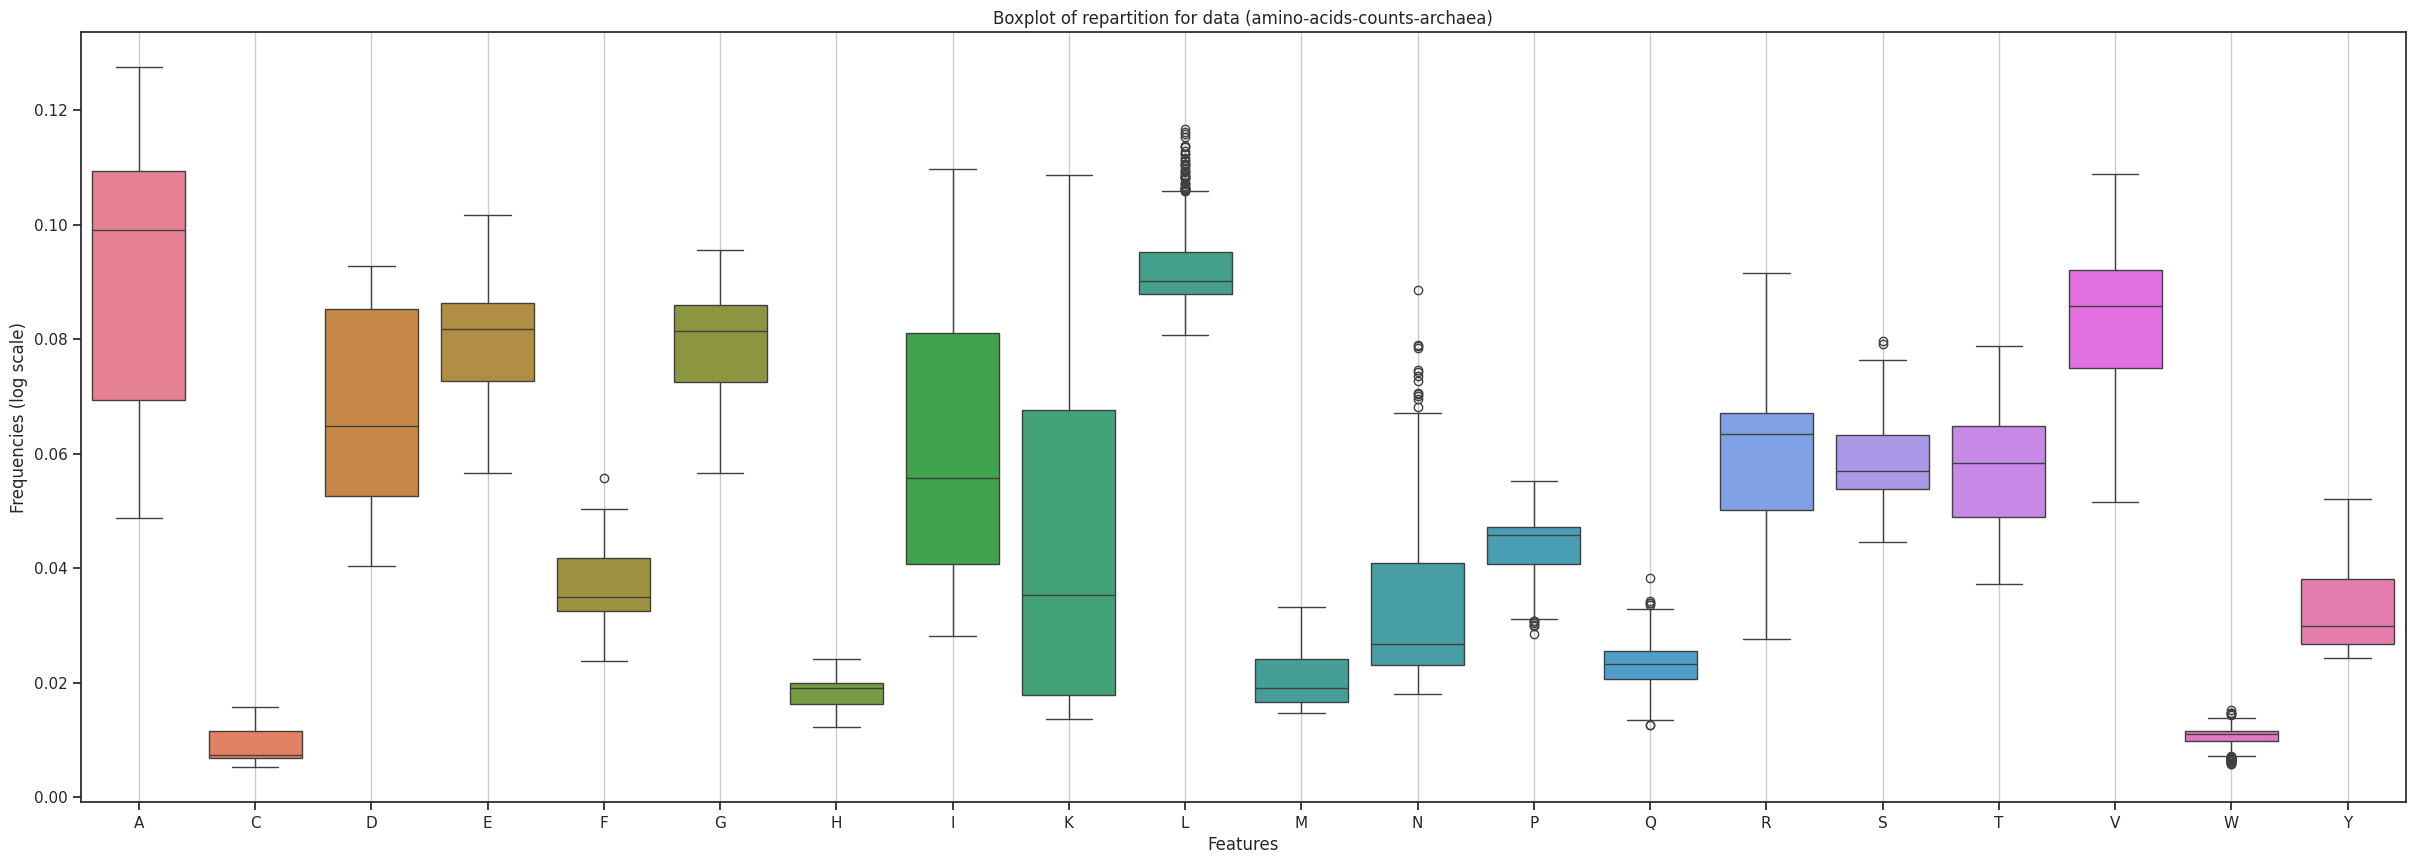

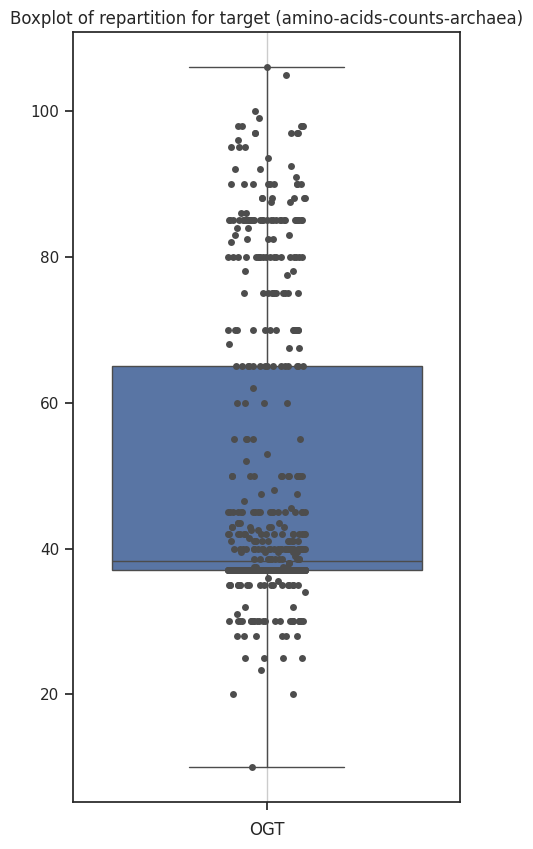

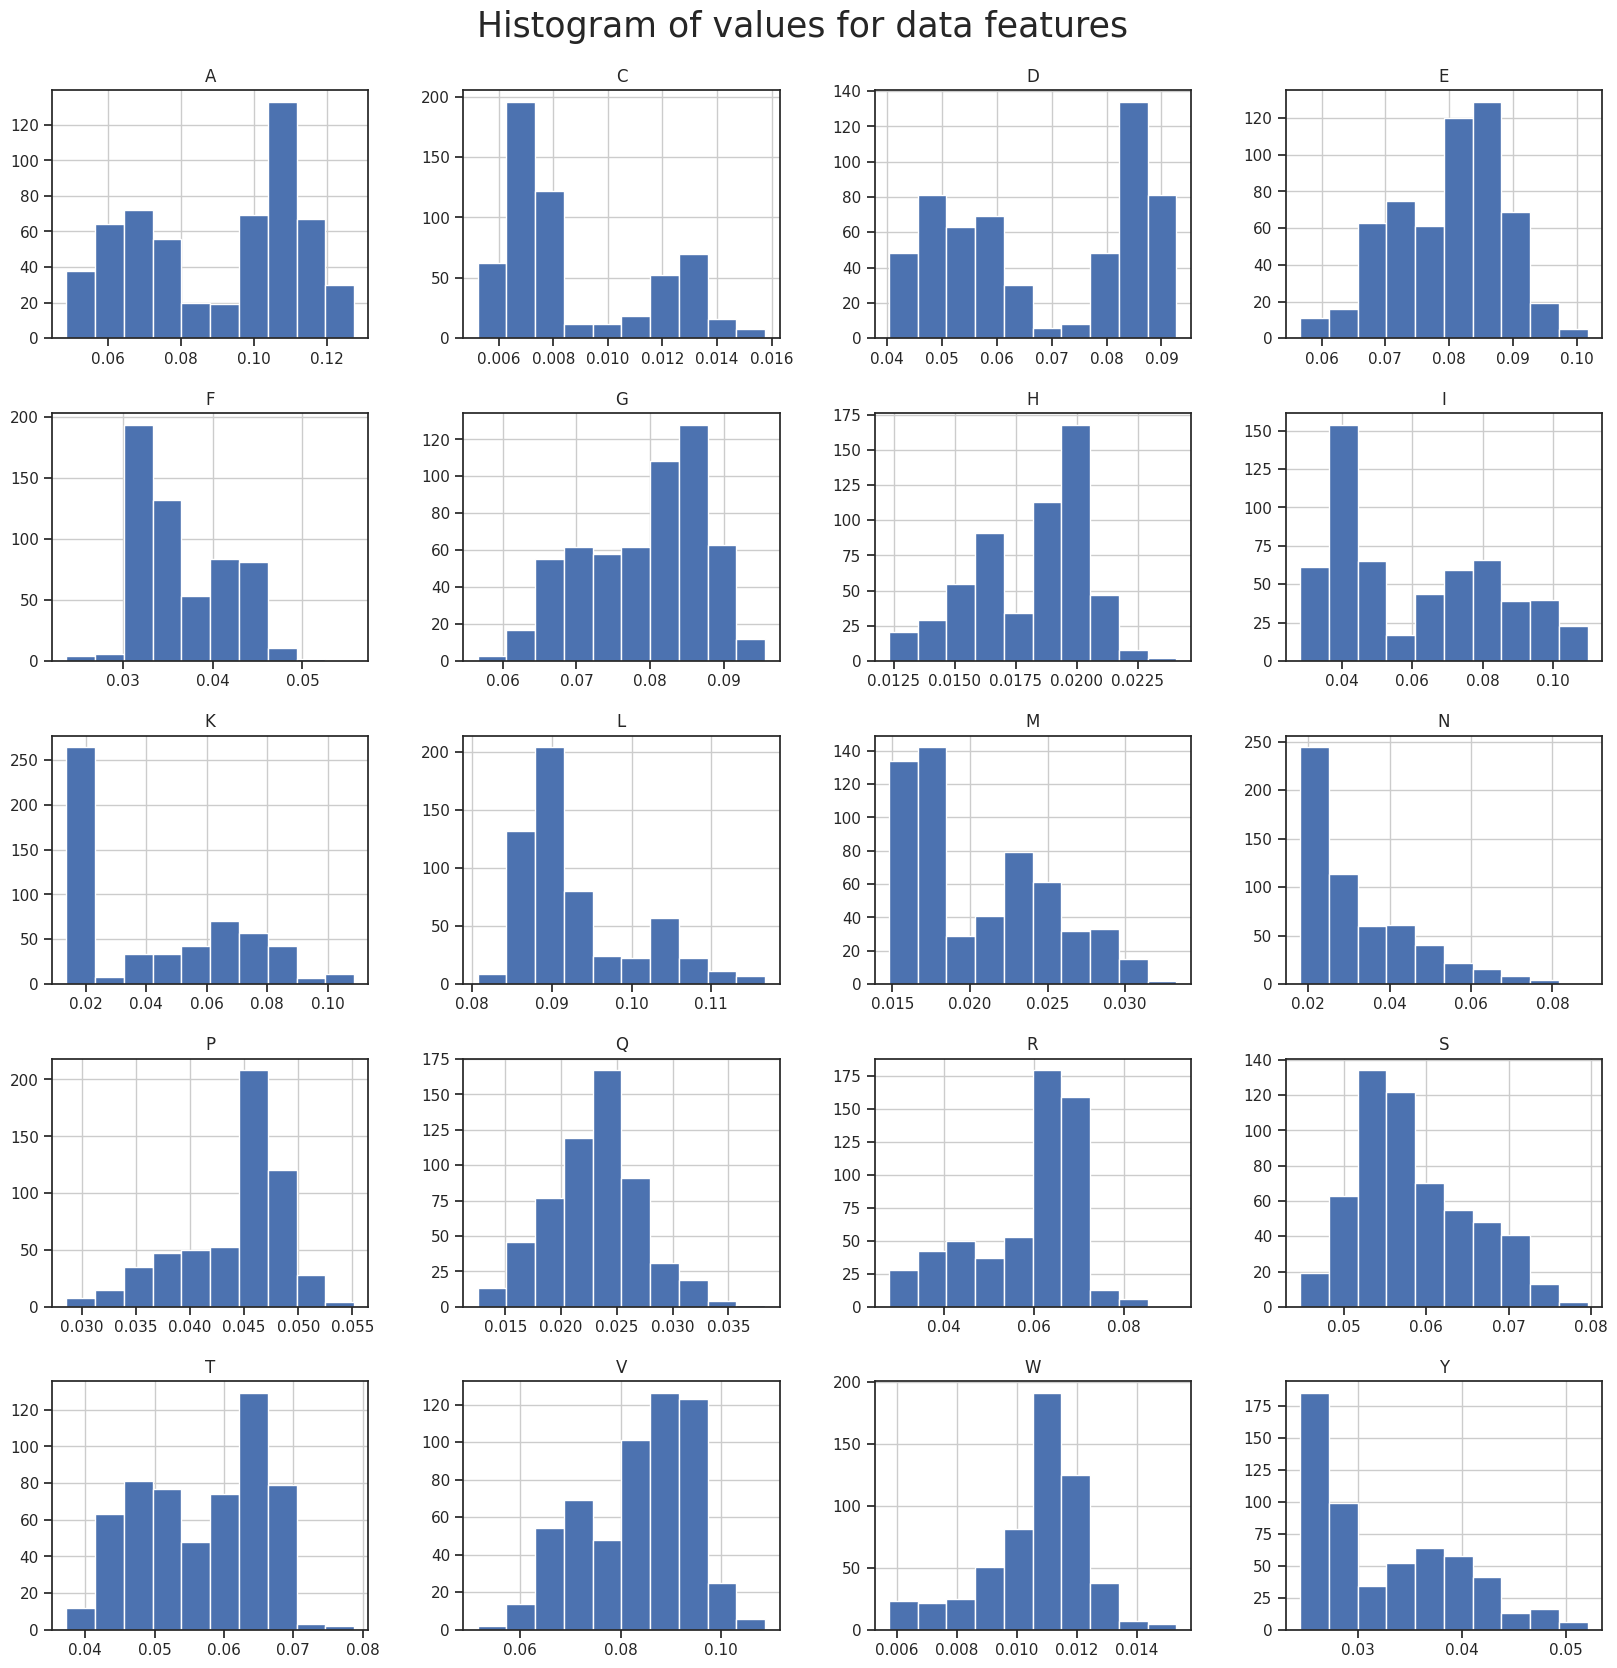

In [4]:
pogt = PredictorOGT(data,target,model,cv,None,exp_name,group)
pogt.run_visualisation_data()

# Prediction with baseline

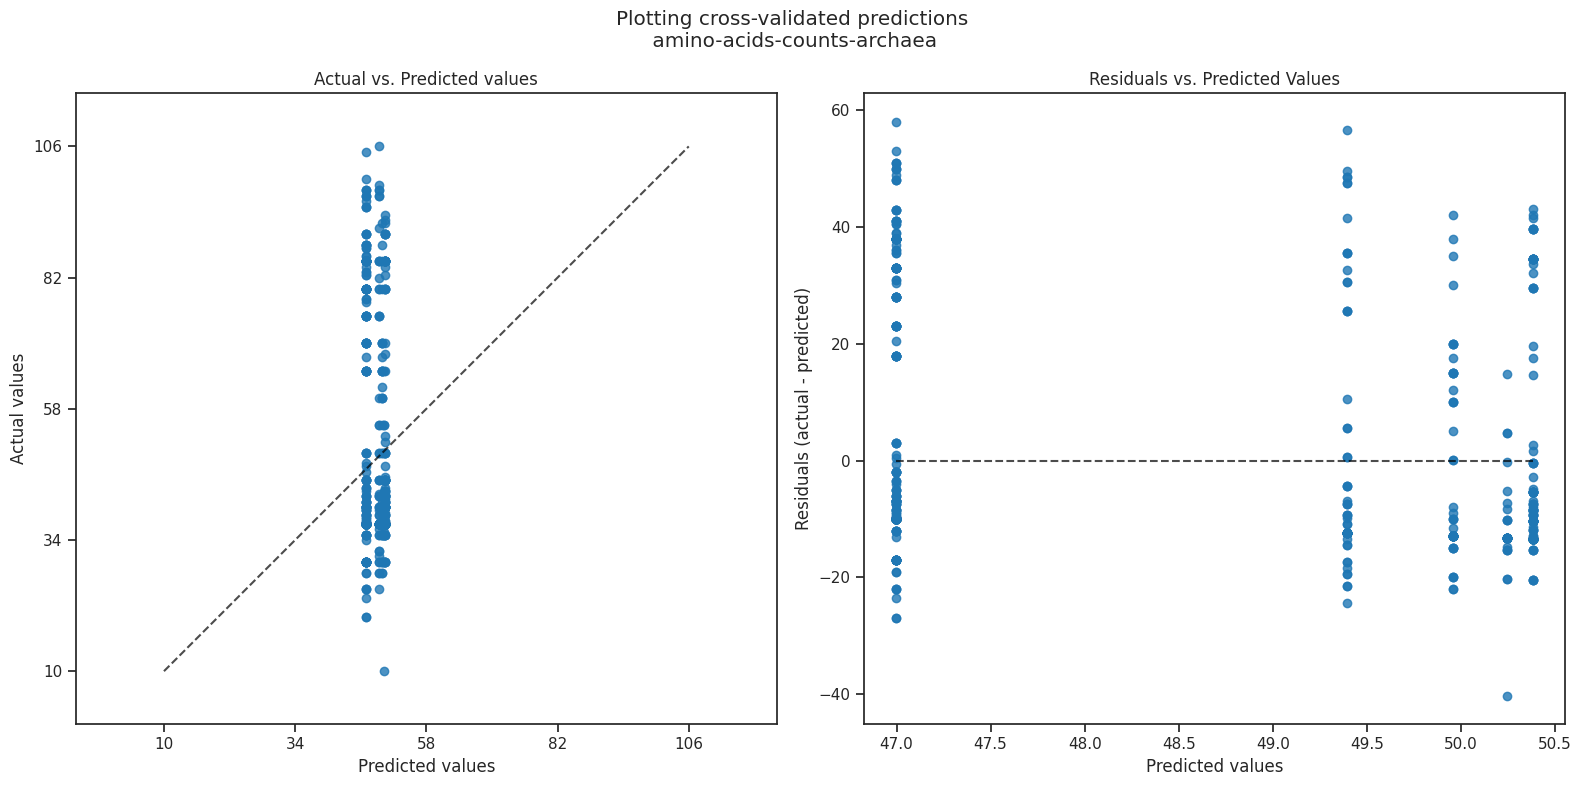

In [7]:
target = pogt.predict_target()

In [6]:
pogt.print_error_estimation()

Mean fit time : 0.000518798828125
Mean score time : 0.0003787040710449219
Mean of error prediction for all CV splits : 16.016756413084742 °C
Mean of r2 for all CV splits : -0.3803877861037861
